In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [2]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (1143, 13)

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [5]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [6]:
print("Wine Quality Counts:")
print(df["quality"].value_counts().sort_index())

Wine Quality Counts:
quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


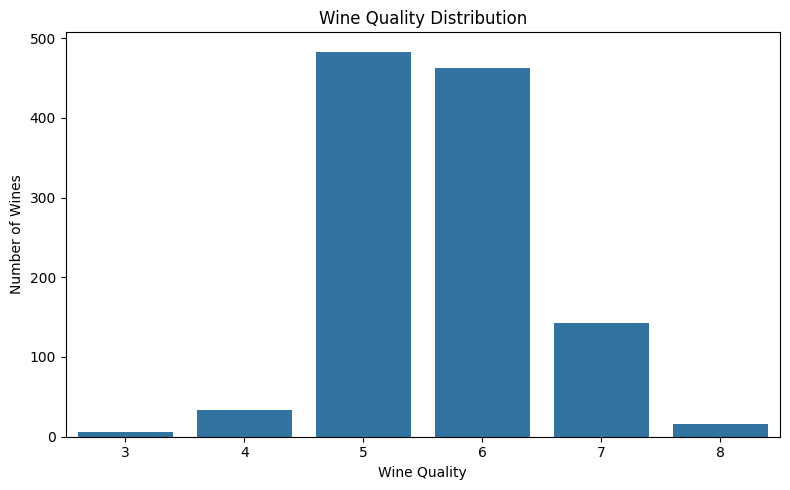

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(x="quality", data=df)

plt.title("Wine Quality Distribution")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.tight_layout()

plt.savefig("quality_distribution.png")
plt.show()

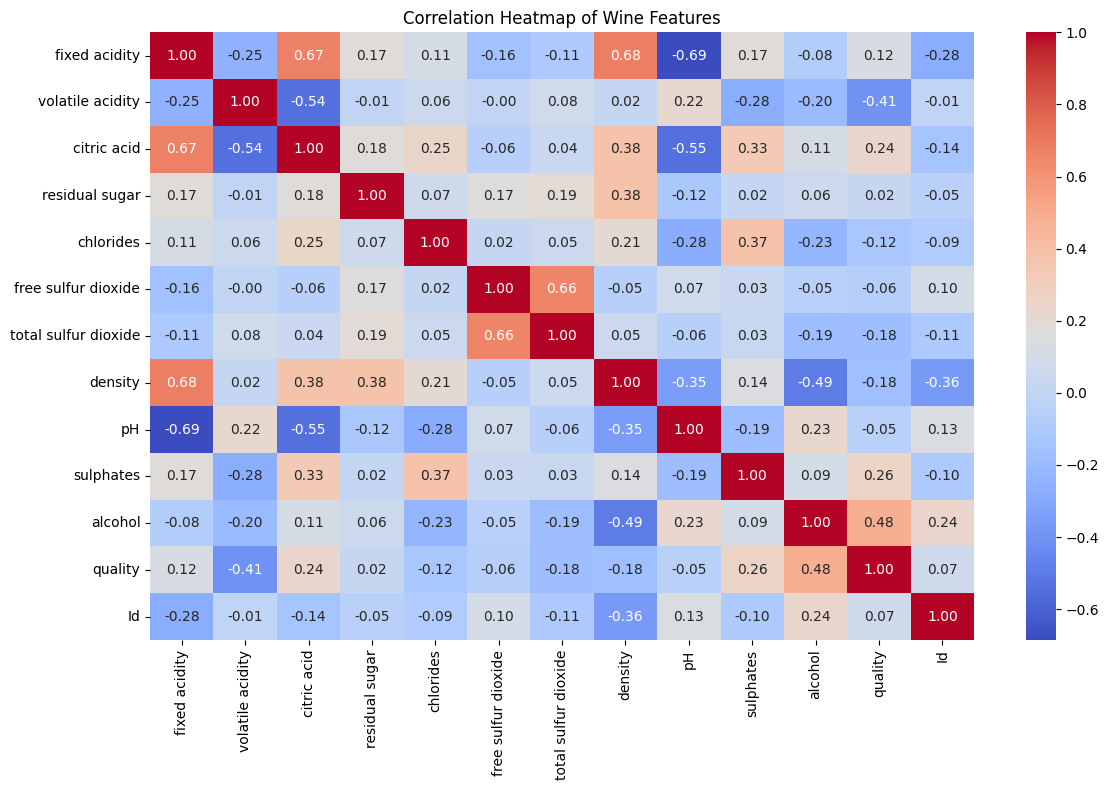

In [8]:
plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap of Wine Features")
plt.tight_layout()

plt.savefig("correlation_heatmap.png")
plt.show()

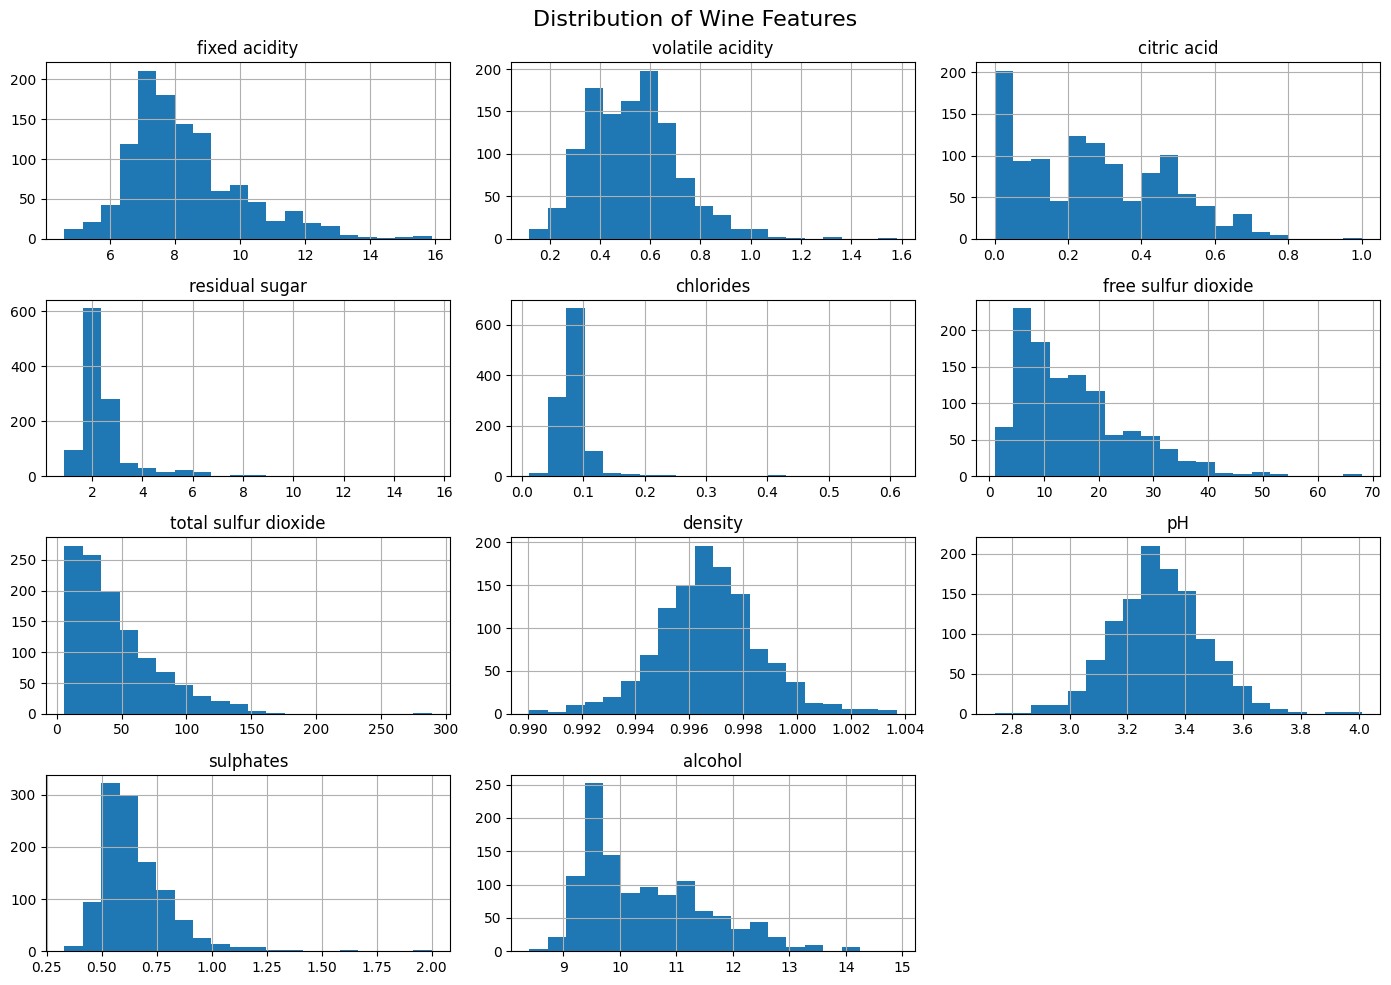

In [9]:
features = [
    "fixed acidity", "volatile acidity", "citric acid",
    "residual sugar", "chlorides", "free sulfur dioxide",
    "total sulfur dioxide", "density", "pH",
    "sulphates", "alcohol"
]

df[features].hist(figsize=(14, 10), bins=20)

plt.suptitle("Distribution of Wine Features", fontsize=16)
plt.tight_layout()
plt.savefig("feature_distributions.png")
plt.show()

In [11]:
def quality_category(quality):
    if quality <= 4:
        return "Low"
    elif quality <= 6:
        return "Medium"
    else:
        return "High"

df["quality_category"] = df["quality"].apply(quality_category)

print(df["quality_category"].value_counts())

quality_category
Medium    945
High      159
Low        39
Name: count, dtype: int64


In [12]:
df[["quality", "quality_category"]].head(10)

,quality,quality_category
0,5,Medium
1,5,Medium
2,5,Medium
3,6,Medium
4,5,Medium
5,5,Medium
6,5,Medium
7,7,High
8,7,High
9,5,Medium


In [13]:
from sklearn.model_selection import train_test_split

# Remove target and ID from input features
X = df.drop(columns=["quality", "quality_category", "Id"])
y = df["quality_category"]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (914, 11)
Testing data: (229, 11)


In [14]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      rf_model.score(X_test, y_test))

Random Forest Accuracy: 0.8602620087336245


In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy:
0.8602620087336245

Classification Report:
              precision    recall  f1-score   support

        High       0.68      0.53      0.60        32
         Low       0.00      0.00      0.00         8
      Medium       0.89      0.95      0.92       189

    accuracy                           0.86       229
   macro avg       0.52      0.49      0.50       229
weighted avg       0.83      0.86      0.84       229



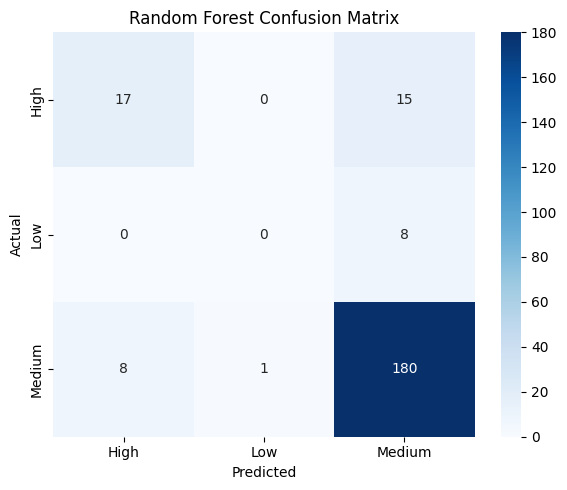

In [16]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig("confusion_matrix_rf.png")
plt.show()

In [17]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train, y_train)

sgd_pred = sgd_model.predict(X_test)

print("SGD Accuracy:",
      accuracy_score(y_test, sgd_pred))

SGD Accuracy: 0.851528384279476


In [18]:
print("SGD Accuracy:")
print(accuracy_score(y_test, sgd_pred))

print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

SGD Accuracy:
0.851528384279476

Classification Report:
              precision    recall  f1-score   support

        High       0.75      0.28      0.41        32
         Low       0.00      0.00      0.00         8
      Medium       0.86      0.98      0.92       189

    accuracy                           0.85       229
   macro avg       0.54      0.42      0.44       229
weighted avg       0.82      0.85      0.82       229



In [19]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel="rbf",
    random_state=42
)

svc_model.fit(X_train, y_train)

svc_pred = svc_model.predict(X_test)

print("SVC Accuracy:",
      accuracy_score(y_test, svc_pred))

SVC Accuracy: 0.8253275109170306


In [20]:
print("SVC Accuracy:")
print(accuracy_score(y_test, svc_pred))

print("\nClassification Report:")
print(classification_report(y_test, svc_pred))

SVC Accuracy:
0.8253275109170306

Classification Report:
              precision    recall  f1-score   support

        High       0.00      0.00      0.00        32
         Low       0.00      0.00      0.00         8
      Medium       0.83      1.00      0.90       189

    accuracy                           0.83       229
   macro avg       0.28      0.33      0.30       229
weighted avg       0.68      0.83      0.75       229



C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

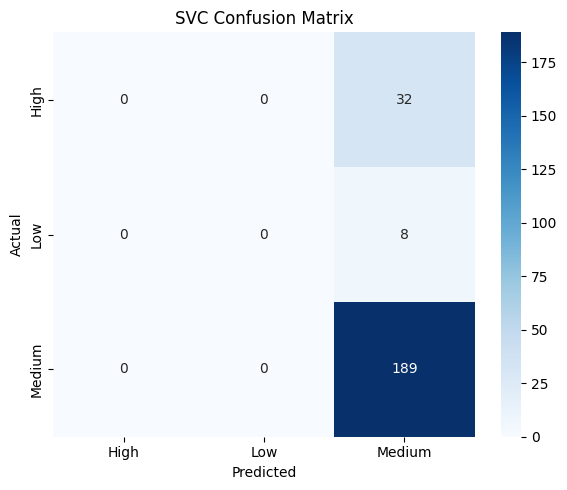

In [21]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, svc_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["High", "Low", "Medium"],
    yticklabels=["High", "Low", "Medium"]
)

plt.title("SVC Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig("confusion_matrix_svc.png")
plt.show()

In [22]:
results = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]
})

print(results)

           Model  Accuracy
0  Random Forest  0.860262
1            SGD  0.851528
2            SVC  0.825328


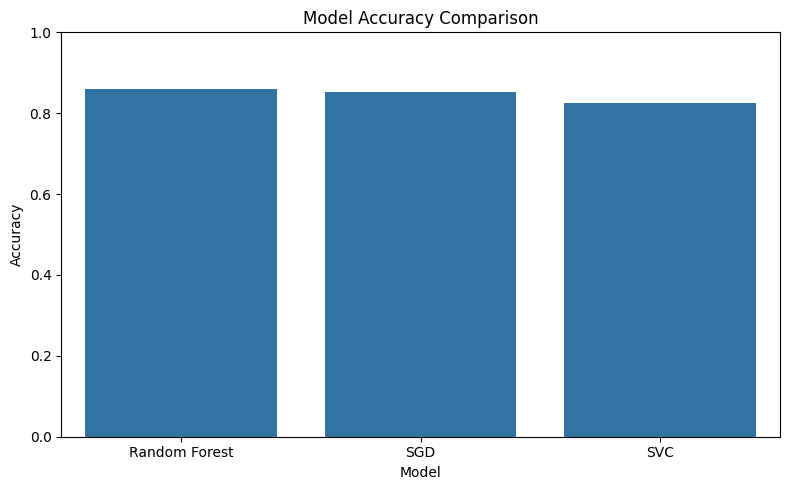

In [23]:
plt.figure(figsize=(8, 5))

sns.barplot(x="Model", y="Accuracy", data=results)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()

plt.savefig("model_comparison.png")
plt.show()

In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                 Feature  Importance
10               alcohol    0.152932
1       volatile acidity    0.126291
9              sulphates    0.102525
7                density    0.096763
2            citric acid    0.087880
4              chlorides    0.086648
0          fixed acidity    0.081416
3         residual sugar    0.074461
6   total sulfur dioxide    0.071365
8                     pH    0.063891
5    free sulfur dioxide    0.055828


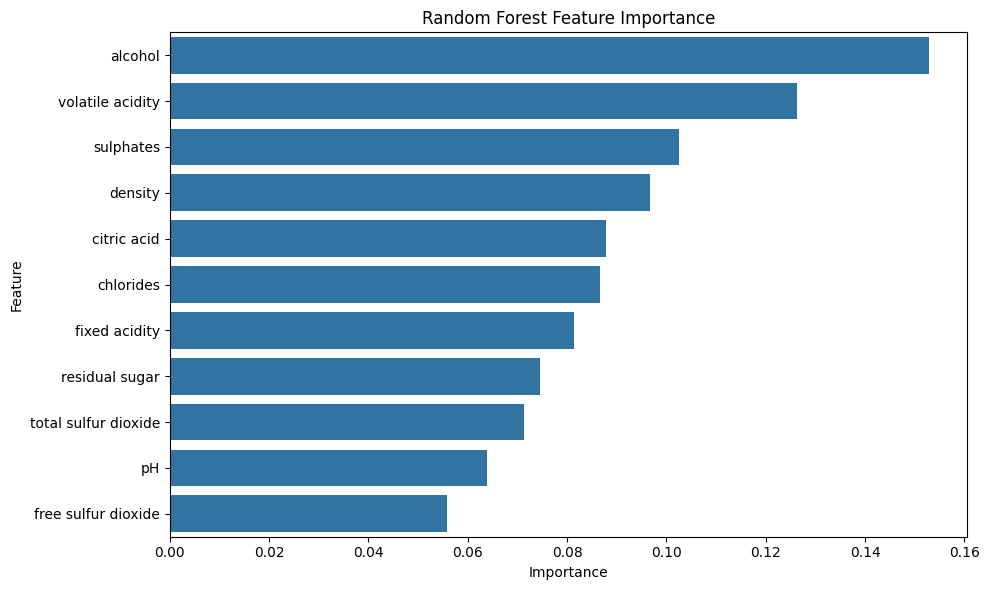

In [25]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig("feature_importance.png")
plt.show()

In [26]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("Model Performance:")
print(results)

print("\nBest Model:")
print(best_model["Model"])

print("Best Accuracy:")
print(round(best_model["Accuracy"], 4))

Model Performance:
           Model  Accuracy
0  Random Forest  0.860262
1            SGD  0.851528
2            SVC  0.825328

Best Model:
Random Forest
Best Accuracy:
0.8603


In [27]:
print("\nConclusion:")
print(
    f"{best_model['Model']} achieved the highest accuracy "
    f"of {best_model['Accuracy']:.2%} among the three models."
)


Conclusion:
Random Forest achieved the highest accuracy of 86.03% among the three models.
